In [ ]:
from google.colab import files

uploaded = files.upload()

Saving practice spreadsheet - Returns.csv to practice spreadsheet - Returns.csv
Saving practice spreadsheet - Orders.csv to practice spreadsheet - Orders.csv
Saving practice spreadsheet - Products.csv to practice spreadsheet - Products.csv
Saving practice spreadsheet - Customers.csv to practice spreadsheet - Customers.csv


In [ ]:
import pandas as pd

customers = pd.read_csv("practice spreadsheet - Customers.csv")
products = pd.read_csv("practice spreadsheet - Products.csv")
orders = pd.read_csv("practice spreadsheet - Orders.csv")
returns = pd.read_csv("practice spreadsheet - Returns.csv")

print("Customers:", customers.shape)
print("Products:", products.shape)
print("Orders:", orders.shape)
print("Returns:", returns.shape)

Customers: (12, 7)
Products: (10, 6)
Orders: (38, 15)
Returns: (3, 4)


In [ ]:
# Check the first 5 rows of each dataset

print("CUSTOMERS")
display(customers.head())

print("PRODUCTS")
display(products.head())

print("ORDERS")
display(orders.head())

print("RETURNS")
display(returns.head())

CUSTOMERS


,customer_id,customer_name,city,clean_city,state,signup_date,segment
0,1001,Aarav Sharma,Pune,Pune,Maharashtra,2024-02-14,Consumer
1,1002,Priya Patil,Nashik,Nashik,Maharashtra,2024-03-21,Consumer
2,1003,Rahul Mehta,Mumbai,Mumbai,Maharashtra,2024-05-09,Corporate
3,1004,Sneha Joshi,Bengaluru,Bengaluru,Karnataka,2024-06-17,Consumer
4,1005,Vikram Singh,Delhi,Delhi,Delhi,2024-07-04,Corporate


PRODUCTS


,product_id,product_name,category,sub_category,cost_price,selling_price
0,P001,Wireless Mouse,Electronics,Accessories,450,699
1,P002,Mechanical Keyboard,Electronics,Accessories,1800,2799
2,P003,Laptop Stand,Office,Accessories,900,1499
3,P004,USB-C Hub,Electronics,Accessories,1100,1799
4,P005,Office Chair,Furniture,Chairs,5200,7999


ORDERS


,order_id,customer_id,order_date,product_id,selling_price,cost_price,quantity,discount,Revenue,profit,profit_margin,payment_method,clean_payment_method,order_status,clean_order_status
0,O1001,1001,2025-01-05,P001,699,450,2,0.05,1328.10,428.10,32.23%,UPI,UPI,Delivered,Delivered
1,O1002,1002,2025-01-08,P005,7999,5200,1,0.10,7199.10,1999.10,27.77%,Card,Card,Delivered,Delivered
2,O1003,1003,2025-01-14,P010,8999,6500,2,0.00,17998.00,4998.00,27.77%,Card,Card,Delivered,Delivered
3,O1004,1004,2025-01-19,P006,299,180,5,0.00,1495.00,595.00,39.80%,UPI,UPI,Delivered,Delivered
4,O1005,1005,2025-01-25,P002,2799,1800,1,0.05,2659.05,859.05,32.31%,Net Banking,Net Banking,Delivered,Delivered


RETURNS


,return_id,order_id,return_date,return_reason
0,R001,O1015,2025-04-27,Damaged product
1,R002,O1007,2025-02-18,Changed mind
2,R003,O1021,2025-07-01,Wrong item


In [ ]:
# Check data types and missing values

print("ORDERS DATA TYPES")
print(orders.dtypes)

print("\nMISSING VALUES")
print(orders.isnull().sum())

ORDERS DATA TYPES
order_id                 object
customer_id               int64
order_date               object
product_id               object
selling_price             int64
cost_price                int64
quantity                  int64
discount                float64
Revenue                 float64
profit                  float64
profit_margin            object
payment_method           object
clean_payment_method     object
order_status             object
clean_order_status       object
dtype: object

MISSING VALUES
order_id                0
customer_id             0
order_date              0
product_id              0
selling_price           0
cost_price              0
quantity                0
discount                0
Revenue                 0
profit                  0
profit_margin           0
payment_method          0
clean_payment_method    0
order_status            0
clean_order_status      0
dtype: int64


In [ ]:
# Convert date to datetime
orders["order_date"] = pd.to_datetime(orders["order_date"])

# Convert profit margin from text to numeric
orders["profit_margin"] = (
    orders["profit_margin"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

print(orders.dtypes[["order_date", "profit_margin"]])

order_date       datetime64[ns]
profit_margin           float64
dtype: object


In [ ]:
# Revenue by product

product_revenue = (
    orders.merge(products[["product_id", "product_name"]],
                 on="product_id")
    .groupby("product_name")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(product_revenue)

product_name
Monitor 24-inch        68842.35
Office Chair           47994.00
Mechanical Keyboard    16234.20
USB-C Hub              12053.30
Notebook Set           10136.10
Laptop Stand            9743.50
Water Bottle            7667.20
Wireless Mouse          7129.80
Desk Lamp               6894.25
Backpack                5921.05
Name: Revenue, dtype: float64


In [ ]:
product_performance = (
    orders.merge(products[["product_id", "product_name", "category"]],
                 on="product_id")
    .groupby(["product_name", "category"])
    .agg(
        revenue=("Revenue", "sum"),
        profit=("profit", "sum"),
        quantity_sold=("quantity", "sum")
    )
    .sort_values("revenue", ascending=False)
)

print(product_performance)

                                  revenue    profit  quantity_sold
product_name        category                                      
Monitor 24-inch     Electronics  68842.35  16842.35              8
Office Chair        Furniture    47994.00  11594.00              7
Mechanical Keyboard Electronics  16234.20   5434.20              6
USB-C Hub           Electronics  12053.30   4353.30              7
Notebook Set        Stationery   10136.10   3836.10             35
Laptop Stand        Office        9743.50   3443.50              7
Water Bottle        Lifestyle     7667.20   3117.20             13
Wireless Mouse      Electronics   7129.80   2179.80             11
Desk Lamp           Furniture     6894.25   2694.25              6
Backpack            Lifestyle     5921.05   2321.05              4


In [ ]:
category_performance = (
    orders.merge(products[["product_id", "category"]], on="product_id")
    .groupby("category")
    .agg(
        revenue=("Revenue", "sum"),
        profit=("profit", "sum"),
        quantity_sold=("quantity", "sum")
    )
    .sort_values("revenue", ascending=False)
)

print(category_performance)

               revenue    profit  quantity_sold
category                                       
Electronics  104259.65  28809.65             32
Furniture     54888.25  14288.25             13
Lifestyle     13588.25   5438.25             17
Stationery    10136.10   3836.10             35
Office         9743.50   3443.50              7


In [ ]:
monthly_revenue = (
    orders
    .groupby(orders["order_date"].dt.to_period("M"))["Revenue"]
    .sum()
)

monthly_revenue.index = monthly_revenue.index.astype(str)

print(monthly_revenue)

order_date
2025-01    30679.25
2025-02    14414.45
2025-03    12174.20
2025-04    10237.50
2025-05    18054.40
2025-06    21443.50
2025-07    20573.30
2025-08     9237.45
2025-09    19368.15
2025-10     4569.55
2025-11    13791.10
2025-12    18072.90
Name: Revenue, dtype: float64


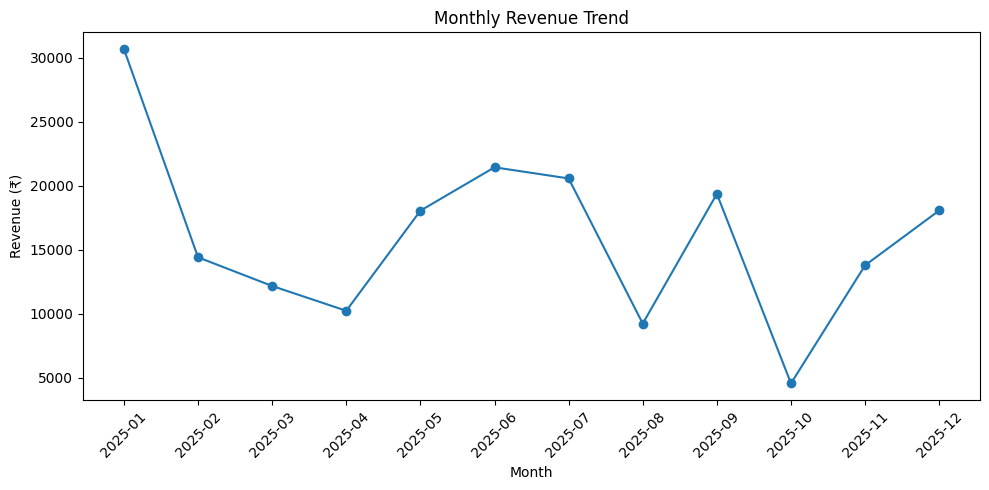

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
payment_revenue = (
    orders
    .groupby("clean_payment_method")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(payment_revenue)

clean_payment_method
Card           113183.60
UPI             58223.65
Net Banking     14314.25
Cash             6894.25
Name: Revenue, dtype: float64


In [ ]:
customer_revenue = (
    orders
    .merge(customers[["customer_id", "customer_name"]], on="customer_id")
    .groupby("customer_name")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(customer_revenue)

customer_name
Meera Iyer       32846.35
Rahul Mehta      31372.15
Karan Shah       28396.45
Priya Patil      19447.45
Neha Kulkarni    14842.70
Vikram Singh     14314.25
Sneha Joshi      10286.20
Aarav Sharma     10164.30
Ananya Rao        9414.10
Isha Nair         7667.20
Rohan Desai       6970.35
Aditya Verma      6894.25
Name: Revenue, dtype: float64


In [ ]:
return_analysis = (
    returns
    .merge(
        orders[["order_id", "Revenue", "customer_id", "product_id"]],
        on="order_id"
    )
)

print(return_analysis)

  return_id order_id return_date    return_reason  Revenue  customer_id  \
0      R001    O1015  2025-04-27  Damaged product   1799.0         1003   
1      R002    O1007  2025-02-18     Changed mind   1499.0         1007   
2      R003    O1021  2025-07-01       Wrong item  14398.2         1009   

  product_id  
0       P004  
1       P009  
2       P005  


In [ ]:
total_orders = len(orders)
total_returns = len(returns)

returned_revenue = return_analysis["Revenue"].sum()
return_rate = (total_returns / total_orders) * 100

print("Total Orders:", total_orders)
print("Total Returns:", total_returns)
print("Return Rate:", round(return_rate, 2), "%")
print("Revenue from Returned Orders: ₹", round(returned_revenue, 2))

Total Orders: 38
Total Returns: 3
Return Rate: 7.89 %
Revenue from Returned Orders: ₹ 17696.2


In [ ]:
city_revenue = (
    orders
    .merge(
        customers[["customer_id", "clean_city"]],
        on="customer_id"
    )
    .groupby("clean_city")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(city_revenue)

clean_city
Mumbai       59768.60
Chennai      32846.35
Pune         25007.00
Nashik       19447.45
Delhi        14314.25
Bengaluru    10286.20
Hyderabad     9414.10
Kochi         7667.20
Ahmedabad     6970.35
Jaipur        6894.25
Name: Revenue, dtype: float64


In [ ]:
orders.to_csv("orders_python_cleaned.csv", index=False)

print("Cleaned orders file saved successfully.")

Cleaned orders file saved successfully.


In [ ]:
from google.colab import files

files.download("orders_python_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>